# Spotify Data Dashboard (Part 1)

Welcome to the Spotify Data Dashboard! This interactive tool, built using the Spotipy library, lets you dive into the world of music with data directly from Spotify. Whether you're exploring top hits, discovering more about your favorite artists, analyzing your recent listening habits, or uncovering popular music genres, this dashboard makes learning about music data both fun and educational.

### What You'll Discover:

* **Top Tracks:** Find out which songs are currently making waves around the world. You’ll see which tracks are the most popular and learn about their artists.

* **Artist Searches:** Have a favorite artist? Search for them and get detailed insights, including their top tracks and related artists. This is a great way to find new music similar to what you already love.

* **Recent Tracks:** Look back at your own Spotify listening history. What songs do you play the most? Are there patterns based on the time of day? Analyzing your personal music trends can be a good reflection of your musical tastes.

* **Top Genres:** Music comes in many styles and genres. Discover which genres are the most popular.

Each section of this dashboard not only provides valuable insights but also includes visual representations like charts and graphs, making the data easy to understand and visually appealing.

## 1. Project Setup

In [ ]:
# Install the spotipy library
!pip install spotipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.0/252.0 kB 4.3 MB/s eta 0:00:00


In [ ]:
# Import libraries for spotipy, dataframe manipulation, and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import spotipy
import collections
from spotipy.oauth2 import SpotifyClientCredentials, SpotifyOAuth


## 2. Boilerplate Code (DON'T EDIT!)

### Authentication & Data-Fetching Functions

This section contains the essential code that powers our Spotify Data Dashboard. Here's a quick rundown of what each part does:

* **Authentication:** These functions handle the login process to Spotify's services. By logging in, our dashboard can access Spotify’s data securely, allowing us to retrieve real-time information about music tracks, artists, and listening habits.

* **Data-Fetching Functions:** Once we're logged in, these functions come into play. They are like special commands that ask Spotify for specific pieces of information.

In [ ]:
### AUTHENTICATION ###

# Authentication setup for accessing Spotify API
def setup_spotify_auth(personal=True):
    """Initialize Spotify client with either personal or client credentials based on the `personal` flag."""
    if personal:
        auth_manager = SpotifyOAuth(
            client_id=YOUR_CLIENT_ID,
            client_secret=YOUR_CLIENT_SECRET,
            redirect_uri="http://localhost:8888/callback",
            scope="user-top-read user-read-recently-played",
            open_browser=False
        )
        return spotipy.Spotify(auth_manager=auth_manager)
    else:
        client_credentials_manager = SpotifyClientCredentials(
            client_id=YOUR_CLIENT_ID,
            client_secret=YOUR_CLIENT_SECRET
        )
        return spotipy.Spotify(client_credentials_manager=client_credentials_manager)


### GLOBAL QUERIES ###

def fetch_top_tracks_global():
    """Fetch the top tracks from Spotify's Global Top 50 playlist and return a DataFrame with track details."""
    top_tracks = sp.playlist_tracks('37i9dQZEVXbMDoHDwVN2tF')  # Spotify's Global Top 50 playlist ID
    tracks = [{
        'name': track['track']['name'],
        'id': track['track']['id'],
        'artist': track['track']['artists'][0]['name'],
        'popularity': track['track']['popularity']
    } for track in top_tracks['items']]
    return pd.DataFrame(tracks)

def fetch_top_tracks_by_artist(artist_name):
    """Fetch top tracks for a given artist by name and return a DataFrame with track details."""
    search_result = sp.search(q=f'artist:{artist_name}', type='artist', limit=1)
    artist = search_result['artists']['items'][0]
    top_tracks = sp.artist_top_tracks(artist['id'])
    tracks = [{
        'name': track['name'],
        'id': track['id'],
        'popularity': track['popularity']
    } for track in top_tracks['tracks']]
    return pd.DataFrame(tracks)

def fetch_audio_features_for_tracks(tracks_df):
    """Fetch audio features for a DataFrame of tracks and return a DataFrame with audio features merged."""
    features = sp.audio_features(tracks_df['id'].tolist())
    features_df = pd.DataFrame(features)
    result_df = pd.merge(tracks_df, features_df, left_on='id', right_on='id', how='left')
    result_df.set_index('name', inplace=True)
    return result_df

def fetch_related_artists(artist_name):
    """Fetch artists related to a given artist by name and return a DataFrame with related artist details."""
    result = sp.search(q=f'artist:{artist_name}', type='artist')
    artist_id = result['artists']['items'][0]['id']
    related_artists = sp.artist_related_artists(artist_id)
    artists = [{
        'name': artist['name'],
        'popularity': artist['popularity']
    } for artist in related_artists['artists']]
    return pd.DataFrame(artists)

def fetch_genre_popularity_global(genres):
    """Fetch popularity of given genres globally and return a DataFrame with genre popularity."""
    genre_popularity = []
    for genre in genres:
        results = sp.search(q=f'genre:"{genre}"', type='artist', limit=50)
        for artist in results['artists']['items']:
            genre_popularity.append((genre, artist['name'], artist['popularity']))
    return pd.DataFrame(genre_popularity, columns=['Genre', 'Artist', 'Popularity'])


### USER QUERIES ###

def fetch_top_tracks_user(limit=10, time_range='long_term'):
    """Fetch the top tracks for the user and return a DataFrame with track details."""
    top_tracks = sp.current_user_top_tracks(limit=limit, time_range=time_range)
    tracks_data = [{
        'name': track['name'],
        'id': track['id'],
        'popularity': track['popularity']
    } for track in top_tracks['items']]
    return pd.DataFrame(tracks_data)

def fetch_top_artists_user(limit=10, time_range='long_term'):
    """Fetch the top artists for the user and return a DataFrame with artist details."""
    top_artists = sp.current_user_top_artists(limit=limit, time_range=time_range)
    artists_data = [{
        'name': artist['name'],
        'popularity': artist['popularity']
    } for artist in top_artists['items']]
    return pd.DataFrame(artists_data)

def fetch_top_genres_user(time_range='long_term'):
    """Fetch the top genres for the user based on top artists and return a sorted list of genres by popularity."""
    top_artists = sp.current_user_top_artists(limit=50, time_range=time_range)
    genre_count = collections.Counter()
    for artist in top_artists['items']:
        for genre in artist['genres']:
            genre_count[genre] += 1
    top_genres = sorted(genre_count.items(), key=lambda x: x[1], reverse=True)
    return pd.DataFrame(top_genres, columns=['Genre', 'Count'])

def fetch_recent_tracks_user():
    """Fetch the last 50 tracks played by the user, analyze by hour, and return a DataFrame with hourly counts."""
    results = sp.current_user_recently_played(limit=50)
    tracks = [{
        'track': item['track']['name'],
        'played_at': item['played_at']
    } for item in results['items']]
    df = pd.DataFrame(tracks)
    df['played_at'] = pd.to_datetime(df['played_at'])
    df['hour'] = df['played_at'].dt.hour
    return df


### PLOTS ###

def radar_chart(df):
  # Create a radar chart
  labels = np.array(df.columns.to_list())
  num_vars = len(labels)

  # Create angle for each axis
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles += angles[:1]  # complete the loop

  # Plot each track
  fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
  for i, row in df.iterrows():
      data = row.tolist()
      data += data[:1]  # complete the loop
      ax.fill(angles, data, alpha=0.25)
      ax.plot(angles, data, label=i)  # Add each track's plot

  # Improve aesthetics
  ax.set_theta_offset(np.pi / 2)
  ax.set_theta_direction(-1)
  ax.set_rlabel_position(0)

  # Draw one axe per variable and add labels
  plt.xticks(angles[:-1], labels)

  # Add legend
  plt.legend(title='Tracks', loc='upper right', bbox_to_anchor=(1.1, 1.1))

## 3. Authentication Setup

This section sets up Spotify authentication, allowing the notebook to fetch data via the Spotipy library. You can switch between personal and client credential flows by setting the `personal` flag.



```
personal = True
YOUR_CLIENT_ID = '4fea4xxxxxxxxxx'
YOUR_CLIENT_SECRET = 'fd2c5xxxxxxxxxx'
```




In [ ]:
personal = True
YOUR_CLIENT_ID = '4fea4c290c8e4c99b4a926acf7296d9a'
YOUR_CLIENT_SECRET = 'fd2c5dead1a34e628cd19dd122834122'

In [ ]:
# Connect to Spotify
sp = setup_spotify_auth(personal=personal)

## 4. Select Data & Visualise

### Get Top Tracks & Artist

* **Global:** This function fetches the top tracks from Spotify's Global Top 50 playlist. It returns a DataFrame containing track names, artists, and popularity.

* **User:** Alternatively you can fetch the top 10 tracks from your personal account. It returns a DataFrame containing track names, artists, and popularity.

✅  Use either the fetch_top_tracks_global() or the fetch_top_tracks_user() function to get the top tracks. Look at the resulting dataframe. Maybe you could sort the titles by popularity?

In [ ]:
top_tracks = fetch_top_tracks_user(limit=10)
top_tracks = top_tracks.sort_values(by='popularity', ascending=False)
top_tracks

Go to the following URL: https://accounts.spotify.com/authorize?client_id=4fea4c290c8e4c99b4a926acf7296d9a&response_type=code&redirect_uri=http%3A%2F%2Flocalhost%3A8888%2Fcallback&scope=user-top-read+user-read-recently-played
Enter the URL you were redirected to: http://localhost:8888/callback?code=AQA-LkiDVUbJ39kEM6nkpvLVeeOm7dVF8l8_Lcyl3_8zM4LNvnE-S9GsgpGhm4XCzs5csBfPP1aj6kfF0-c2mhL26BQf0ZUvd9tRHql-zfU8mjt6v9fNDvuIxvKjuYQ7dvhnAzwY-krVBAV5XiVFk-oahYwoYXVhzH9LQNexFUOSw-BkWyUn0iYdo2EKh3XRt24_HyVvAh-sid1tQBwgmmU89eRZ5bDhjX37VA


,name,id,popularity
8,Rush,1rrqJ9QkOBYJlsZgqqwxgB,67
4,Mi Música - Remasterizado,24hmqfTZpZ1xEb21qmOqFL,34
5,Bicho Malo,3WvbHKoGHjUdoyyfmcCeOE,31
0,La Chica Chocolate,4x63ATVTkH4p48gHOtBpUA,29
9,La Lámpara,2c7nzxJYmPtkimDdrhcfJx,27
6,Nube Pasajera,1vqojH8o4mxfyP2qJF0vyb,21
2,Tú No Suenas,3hBcWSRgD5S1LCZftZydx8,19
1,Sin Susto,61dskWyeA7FborJjVmkCZW,17
3,Que Clase de Cara,2Xs7P1s8rfGElBuQ1hYHa9,11
7,Princesa (Timba),6hc49zBl1Yd1Oz0DWAA5oq,9


❓  What type of plot would you use to visualise this data?

<ipython-input-7-1831cbb1813c>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


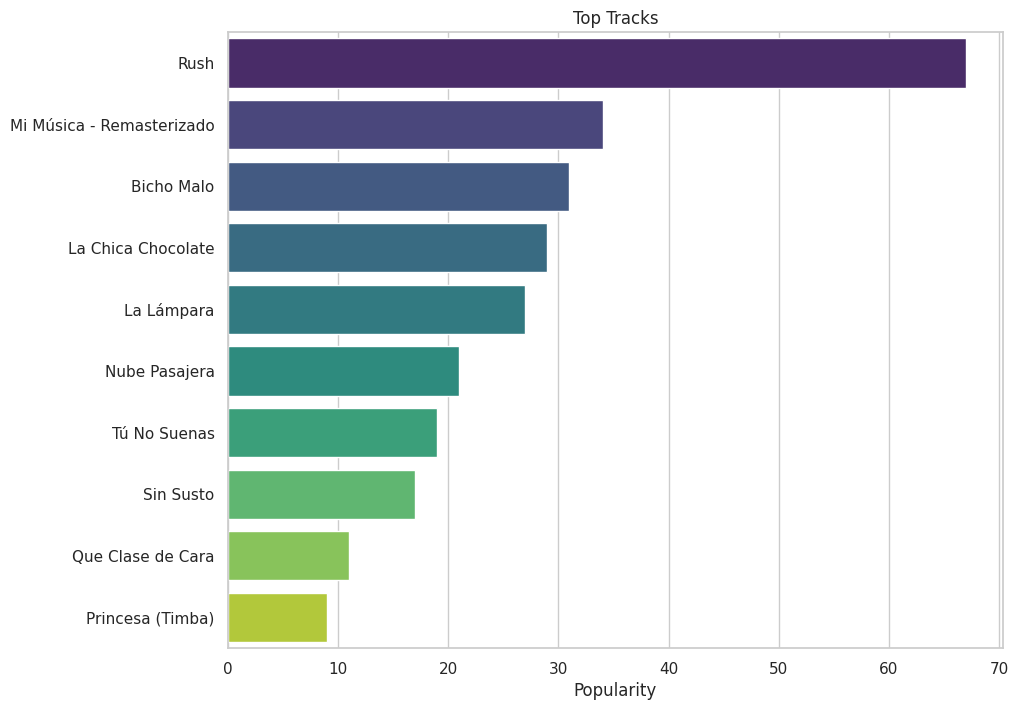

In [ ]:
data = top_tracks # optionally filter (e.g. only 10 tracks)
colour = 'viridis'  # You can choose different color palettes like 'viridis', 'rocket', etc.

### PLOT ###

sns.set(style="whitegrid")  # Set the aesthetic style of the plots
plt.figure(figsize=(10, 8))

bar_plot = sns.barplot(
    x='popularity',  # Make sure this corresponds to your column name
    y='name',  # Make sure this corresponds to your column name
    data=data,
    palette=colour
)

# Set the title and labels
plt.title('Top Tracks')
plt.xlabel('Popularity')
plt.ylabel('')

# bar_plot.invert_yaxis()  # Invert the y-axis to have the top track on top
plt.show()

❓  What other information can we fetch with the Spotify API?

✅  Use either the fetch_top_tracks_by_artist() or the fetch_top_artists_user() function to make another barplot.

In [ ]:
top_artists = fetch_top_artists_user(limit=10)
top_artists = top_artists.sort_values(by='popularity', ascending=False)
top_artists

,name,popularity
0,Havana D’Primera,49
1,Alexander Abreu,49
5,C4 Pedro,47
7,Neyna,46
9,Alexander Abreu and Havana D' Primera,34
6,Lil Saint,33
8,Formell y los Van Van,33
3,Calle Real,27
2,Manana Club,26
4,Papucho Manana Club,21


### Get Similar Artists

* **Global:** This function searches for and retrieves artists related to a given main artist. This is particularly useful for discovering new music similar to your favorite artists and for exploring broader music connections within genres.

✅  Use either the fetch_related_artists() to fetch artists that are similar to an artist of your choice. Look at the resulting dataframe.

In [ ]:
artist_name = 'Calle Real'
related_artists = fetch_related_artists(artist_name)
related_artists.head()

,name,popularity
0,Manana Club y Papucho,1
1,Grupo Danson,16
2,Azucar Negra,21
3,Tirso Duarte y La Mecanica Loca,20
4,Angel Yos,15


❓  What type of plot would you use to visualise this data?

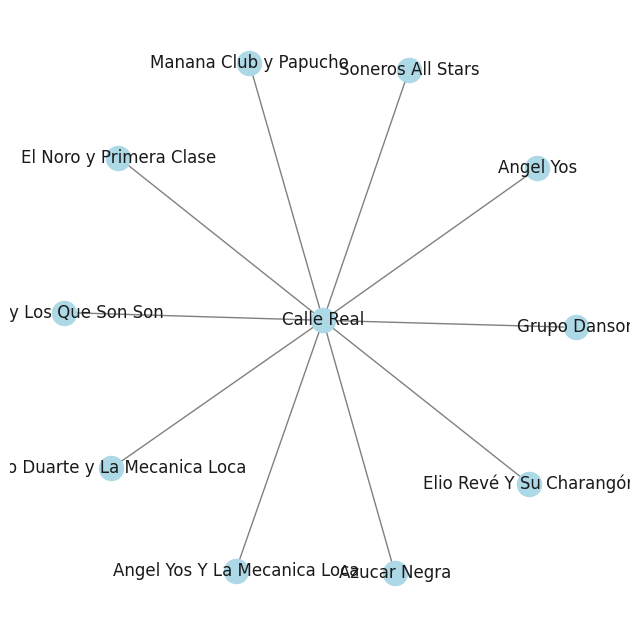

In [ ]:
data = related_artists.head(10) # optionally filter (e.g. only 10 tracks)
colour = 'lightblue'  # You can choose different colors like 'coral', 'green', etc.

### PLOT ###

G = nx.Graph()

G.add_node(artist_name)  # Add the main artist as a node

# Add related artists
for index, artist in data.iterrows():
    G.add_node(artist['name'])  # Add related artist
    G.add_edge(artist_name, artist['name'])  # Create an edge between main artist and related artist

fig, ax = plt.subplots(figsize=(8, 8))
pos = nx.spring_layout(G, seed=7)  # Positions for all nodes
nx.draw(G, pos, with_labels=True, node_color=colour, edge_color='gray')

plt.show()

### Get Track Audio Features

* **Global:** This function fetches detailed audio features for a list of tracks. It includes key acoustic attributes such as danceability, energy, speechiness, acousticness, and instrumentalness.These features can help in understanding the musical components that make up each track, useful for audio analysis, DJing, etc.

✅  Use the fetch_audio_features_for_tracks() function to fetch the audio features (e.g. danceability) of one or more songs. Look at the resulting dataframe. Then select 3-5 features to visualise.

In [ ]:
audio_features = fetch_audio_features_for_tracks(top_tracks)
audio_features

,id,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,uri,track_href,analysis_url,duration_ms,time_signature
name,,,,,,,,,,,,,,,,,,,
Rush,1rrqJ9QkOBYJlsZgqqwxgB,67,0.792,0.503,1,-8.044,1,0.0626,0.0369,0.000570,0.0959,0.381,99.970,audio_features,spotify:track:1rrqJ9QkOBYJlsZgqqwxgB,https://api.spotify.com/v1/tracks/1rrqJ9QkOBYJ...,https://api.spotify.com/v1/audio-analysis/1rrq...,185093,4
Mi Música - Remasterizado,24hmqfTZpZ1xEb21qmOqFL,34,0.759,0.871,4,-4.141,0,0.0499,0.7320,0.000001,0.0560,0.873,95.015,audio_features,spotify:track:24hmqfTZpZ1xEb21qmOqFL,https://api.spotify.com/v1/tracks/24hmqfTZpZ1x...,https://api.spotify.com/v1/audio-analysis/24hm...,347153,4
Bicho Malo,3WvbHKoGHjUdoyyfmcCeOE,31,0.541,0.709,9,-7.394,0,0.0661,0.3320,0.000190,0.2720,0.811,155.983,audio_features,spotify:track:3WvbHKoGHjUdoyyfmcCeOE,https://api.spotify.com/v1/tracks/3WvbHKoGHjUd...,https://api.spotify.com/v1/audio-analysis/3Wvb...,331880,4
La Chica Chocolate,4x63ATVTkH4p48gHOtBpUA,29,0.762,0.928,11,-5.693,0,0.0492,0.2040,0.000000,0.1620,0.907,102.444,audio_features,spotify:track:4x63ATVTkH4p48gHOtBpUA,https://api.spotify.com/v1/tracks/4x63ATVTkH4p...,https://api.spotify.com/v1/audio-analysis/4x63...,446694,4
La Lámpara,2c7nzxJYmPtkimDdrhcfJx,27,0.661,0.888,7,-5.652,0,0.0429,0.3670,0.000019,0.2860,0.875,96.049,audio_features,spotify:track:2c7nzxJYmPtkimDdrhcfJx,https://api.spotify.com/v1/tracks/2c7nzxJYmPtk...,https://api.spotify.com/v1/audio-analysis/2c7n...,303623,4
Nube Pasajera,1vqojH8o4mxfyP2qJF0vyb,21,0.480,0.928,1,-5.898,0,0.0445,0.4650,0.000351,0.1050,0.516,106.974,audio_features,spotify:track:1vqojH8o4mxfyP2qJF0vyb,https://api.spotify.com/v1/tracks/1vqojH8o4mxf...,https://api.spotify.com/v1/audio-analysis/1vqo...,413080,4
Tú No Suenas,3hBcWSRgD5S1LCZftZydx8,19,0.769,0.897,8,-3.064,1,0.0378,0.5280,0.000052,0.0990,0.892,94.997,audio_features,spotify:track:3hBcWSRgD5S1LCZftZydx8,https://api.spotify.com/v1/tracks/3hBcWSRgD5S1...,https://api.spotify.com/v1/audio-analysis/3hBc...,293000,4
Sin Susto,61dskWyeA7FborJjVmkCZW,17,0.631,0.986,11,-1.637,0,0.0744,0.5810,0.000008,0.0817,0.865,192.039,audio_features,spotify:track:61dskWyeA7FborJjVmkCZW,https://api.spotify.com/v1/tracks/61dskWyeA7Fb...,https://api.spotify.com/v1/audio-analysis/61ds...,297930,4
Que Clase de Cara,2Xs7P1s8rfGElBuQ1hYHa9,11,0.851,0.888,6,-3.471,0,0.0501,0.6530,0.000016,0.1000,0.953,99.947,audio_features,spotify:track:2Xs7P1s8rfGElBuQ1hYHa9,https://api.spotify.com/v1/tracks/2Xs7P1s8rfGE...,https://api.spotify.com/v1/audio-analysis/2Xs7...,325800,4


In [ ]:
selected_features = ['danceability', 'energy', 'acousticness']
df_selected = audio_features[selected_features].head(2)
df_selected

,danceability,energy,acousticness
name,,,
Rush,0.792,0.503,0.0369
Mi Música - Remasterizado,0.759,0.871,0.7320


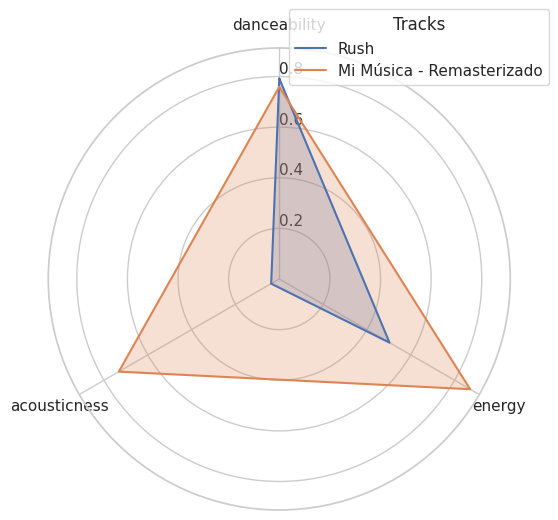

In [ ]:
radar_chart(df_selected)

### Get Top Genres

* **Global:** This function fetches the popularity of given genres globally. It returns a DataFrame with the genre, artist names, and their popularity. This information is useful for understanding which genres are trending worldwide and identifying popular artists within those genres.

* **User:** This function retrieves the user's top genres based on their listening history. It includes data on the popularity of genres and specific artists the user listens to, providing insights into the user's musical preferences.

✅  Use fetch_genre_popularity_global() to get the most popular artists of each genre. Alternatively, use the fetch_top_genres_user() function to get your top genres. Look at the resulting dataframe.

In [ ]:
genres = ['rock', 'pop', 'hip-hop', 'electronic', 'classical']  # Define genres to search
genre_popularity = fetch_genre_popularity_global(genres)
genre_popularity.head()

,Genre,Artist,Popularity
0,rock,Mac DeMarco,78
1,rock,Queen,83
2,rock,Daft Punk,79
3,rock,Elvis Presley,77
4,rock,U2,76


([0, 1, 2, 3, 4],
 [Text(0, 0, 'rock'),
  Text(1, 0, 'pop'),
  Text(2, 0, 'hip-hop'),
  Text(3, 0, 'electronic'),
  Text(4, 0, 'classical')])

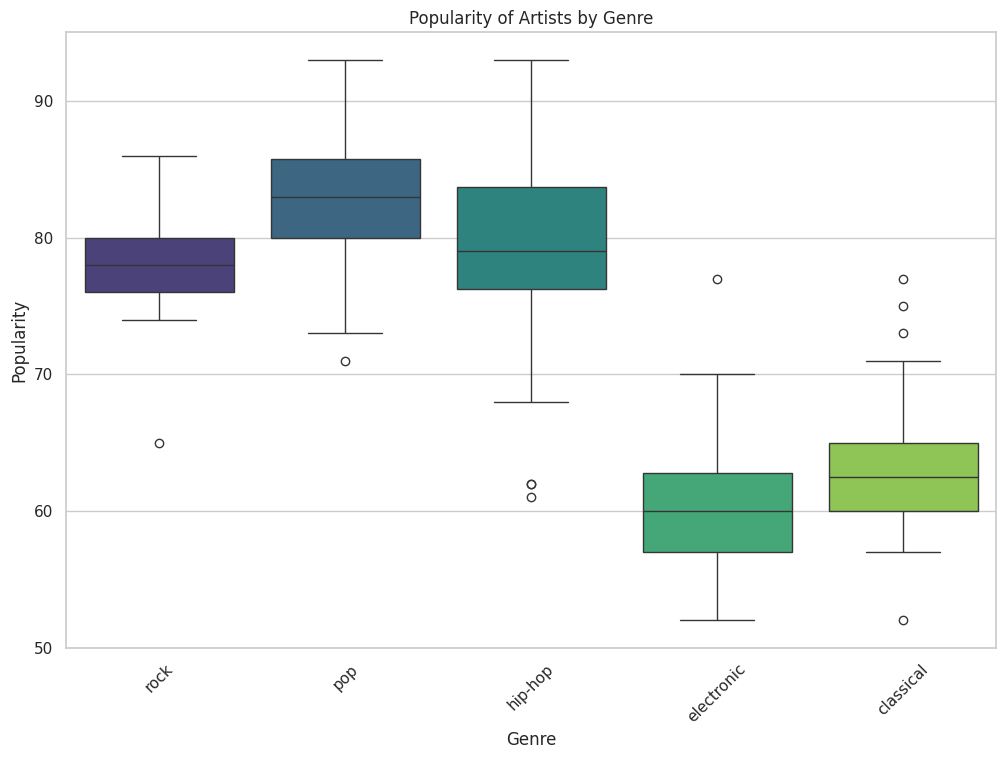

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))
sns.boxplot(
    x='Genre',
    y='Popularity',
    data=genre_popularity,
    hue='Genre',
    palette='viridis'
)
plt.title('Popularity of Artists by Genre')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.xticks(rotation=45)

In [ ]:
# Display user top genres
top_genres = fetch_top_genres_user()
top_genres.head()

,Genre,Count
0,timba,11
1,kizomba,9
2,salsa cubana,8
3,modern salsa,4
4,r&b francais,4


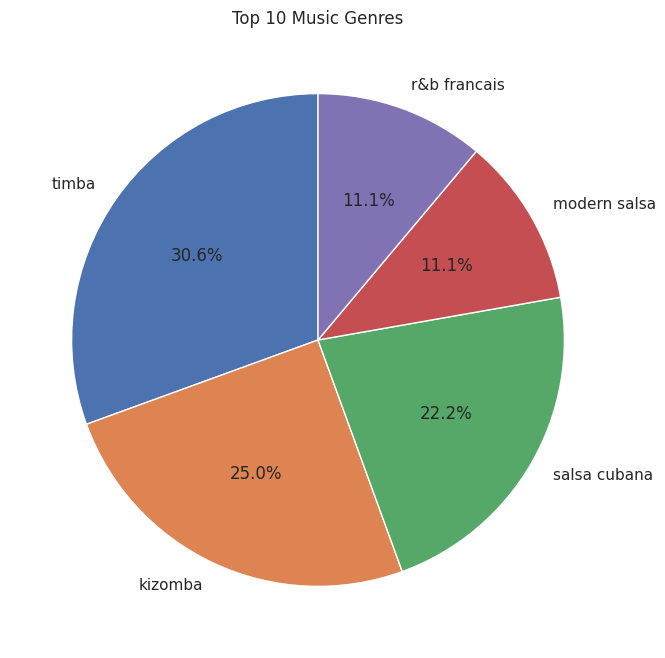

In [ ]:
# Plotting
data = top_genres.head(5)  # Get top 5 genres and their counts

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(data['Count'], labels=data['Genre'], autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Music Genres')
plt.show()

### Get Listening Activity

* **User:** This function fetches recent tracks listened to by the user and analyzes their listening activity by the hour. The resulting data provides insights into the times of day the user is most active in listening to music, which can be useful for understanding daily listening habits and preferences.

In [ ]:
recent_tracks = fetch_recent_tracks_user()
recent_tracks.head()

,track,played_at,hour
0,Recuerdos,2024-06-20 16:41:42.998000+00:00,16
1,Resumen de los 90 - Remasterizado,2024-06-20 16:37:04.710000+00:00,16
2,Recuerdos,2024-06-20 16:29:45.165000+00:00,16
3,Sin Susto,2024-06-19 19:45:12.784000+00:00,19
4,Resumen de los 90 - Remasterizado,2024-06-19 13:34:25.332000+00:00,13


In [ ]:
# Count the number of tracks played each hour and sort the counts by hour
hourly_counts = recent_tracks['hour'].value_counts().sort_index()
hourly_counts

hour
1     4
10    3
11    5
12    5
13    8
15    7
16    7
18    2
19    6
21    3
Name: count, dtype: int64

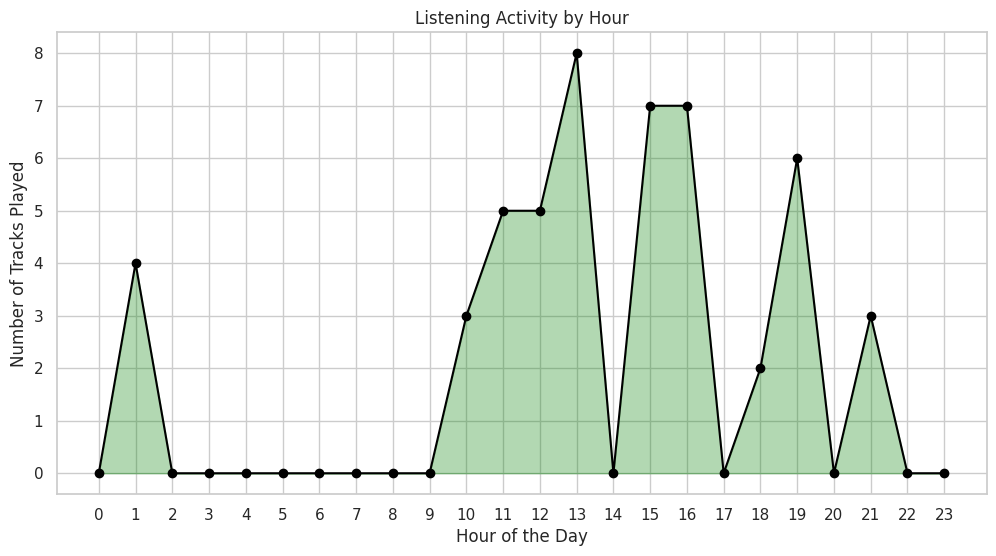

In [ ]:
# Ensure all hours are represented in the data, even those with zero plays
hourly_counts = hourly_counts.reindex(range(24), fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(hourly_counts.index, hourly_counts, marker='o', linestyle='-', color='black')
plt.fill_between(hourly_counts.index, hourly_counts, color='green', alpha=0.3)
plt.title('Listening Activity by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Tracks Played')
plt.xticks(range(0, 24))  # Set x-ticks to show every hour
plt.grid(True)
plt.show()